# Kerchunk vs NetCDF Read Performance for Single-File Datasets

For single-file datasets, the number of time steps significantly impacts read time. Fewer time steps (<10k) result in slower Kerchunk read times compared to netCDF, while more time steps improve Kerchunk's relative performance.

**Overview**

- Compares read performance of Kerchunk references and native netCDF files across CMIP frequencies for single-file datasets.

**Key Findings**

- Kerchunk read times are slower for datasets with fewer time steps (~1-2k) when there is only one netCDF file. However, the read times are still < 1 sec and the difference is marginal.
- As time steps increase (>~10k), Kerchunk maintains a performance advantage for larger datasets.

**Conclusion**

- Kerchunk is efficient for single-file datasets, demonstrating scalability even with increasing time steps.
- The performance gap between Kerchunk and netCDF widens for larger datasets, highlighting Kerchunk's advantage in handling high-resolution data.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML

# Prevent truncation of strings
pd.set_option("display.max_colwidth", None)
# Display floats with two decimal places
pd.options.display.float_format = "{:.2f}".format

## Load Raw Metrics


In [2]:
df_raw = pd.read_csv(
    "riotai/results/20260126_130127/kerchunk_vs_netcdf_raw_20260126_130127.csv"
)

# Add a new column for the difference between kerchunk_time and netcdf_time
df_raw["time_difference"] = df_raw["kerchunk_time"] - df_raw["netcdf_time"]

## Filter on single netCDF datasets


In [3]:
df_raw_sorted = df_raw.sort_values(by="time_difference", ascending=False)

# Create a new DataFrame without 3hr (outliers) and with num_netcdf_files = 1
df_no_3hr_single_file = df_raw_sorted[
    (df_raw_sorted["frequency"] != "3hr") & (df_raw_sorted["num_netcdf_files"] == 1)
]
df_no_3hr_single_file = df_no_3hr_single_file.sort_values(
    by="time_difference", ascending=False
)

HTML(
    f"""
<div style="height:400px; overflow-y:scroll;">
    {df_no_3hr_single_file.head(n=10).to_html(max_rows=None, max_cols=None, notebook=True)}
</div>
"""
)

,frequency,json,num_netcdf_files,timesteps,dims,kerchunk_time,netcdf_time,time_difference
1,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/ssp119/mon/CMIP6.ScenarioMIP.IPSL.IPSL-CM6A-LR.ssp119.r6i1p1f1.Amon.tas.gr.v20191122.kerchunk.json,1,1032,"{'time': 1032, 'lat': 143, 'lon': 144, 'axis_nbounds': 2}",0.70,0.24,0.47
0,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/historical/mon/CMIP6.CMIP.CNRM-CERFACS.CNRM-CM6-1.historical.r14i1p1f2.Amon.tas.gr.v20191004.kerchunk.json,1,1980,"{'time': 1980, 'lat': 128, 'lon': 256, 'axis_nbounds': 2}",0.52,0.17,0.35
21,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/ssp370/mon/CMIP6.ScenarioMIP.IPSL.IPSL-CM6A-LR.ssp370.r2i1p1f1.Amon.tas.gr.v20190119.kerchunk.json,1,1032,"{'time': 1032, 'lat': 143, 'lon': 144, 'axis_nbounds': 2}",0.58,0.26,0.32
6,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/ssp370/mon/CMIP6.ScenarioMIP.IPSL.IPSL-CM6A-LR.ssp370.r1i1p1f1.Amon.tas.gr.v20190119.kerchunk.json,1,1032,"{'time': 1032, 'lat': 143, 'lon': 144, 'axis_nbounds': 2}",0.29,0.23,0.06
14,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/historical/mon/CMIP6.CMIP.IPSL.IPSL-CM6A-LR.historical.r5i1p1f1.Amon.tas.gr.v20180803.kerchunk.json,1,1980,"{'time': 1980, 'lat': 143, 'lon': 144, 'axis_nbounds': 2}",0.33,0.33,0.00
35,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/historical/mon/CMIP6.CMIP.CNRM-CERFACS.CNRM-ESM2-1.historical.r11i1p1f2.Amon.tas.gr.v20200408.kerchunk.json,1,1980,"{'time': 1980, 'lat': 128, 'lon': 256, 'axis_nbounds': 2}",0.29,0.39,-0.10
8,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/pr/highresSST-present/mon/CMIP6.HighResMIP.IPSL.IPSL-CM6A-ATM-HR.highresSST-present.r1i1p1f1.Amon.pr.gr.v20190122.kerchunk.json,1,780,"{'time': 780, 'lat': 361, 'lon': 512, 'axis_nbounds': 2}",0.24,0.56,-0.32
76,day,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/pr/highresSST-present/day/CMIP6.HighResMIP.IPSL.IPSL-CM6A-ATM-HR.highresSST-present.r1i1p1f1.day.pr.gr.v20190122.kerchunk.json,1,23741,"{'time': 23741, 'lat': 361, 'lon': 512, 'axis_nbounds': 2}",0.57,6.22,-5.65
40,day,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/historical/day/CMIP6.CMIP.IPSL.IPSL-CM6A-LR.historical.r22i1p1f1.day.tas.gr.v20190614.kerchunk.json,1,60265,"{'time': 60265, 'lat': 143, 'lon': 144, 'axis_nbounds': 2}",4.51,13.14,-8.64
78,day,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/historical/day/CMIP6.CMIP.IPSL.IPSL-CM6A-LR.historical.r25i1p1f1.day.tas.gr.v20190614.kerchunk.json,1,60265,"{'time': 60265, 'lat': 143, 'lon': 144, 'axis_nbounds': 2}",0.99,9.77,-8.78


## Plot 1 - Kerchunk vs NetCDF Read Time for Single netCDF Datasets


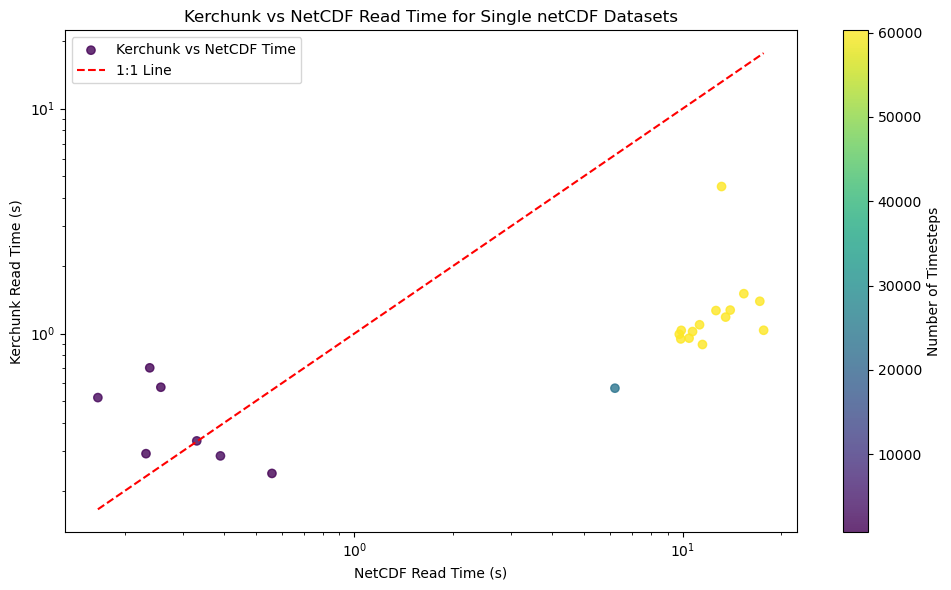

In [4]:
# Plot kerchunk_time vs netcdf_time using matplotlib
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_no_3hr_single_file["netcdf_time"],
    df_no_3hr_single_file["kerchunk_time"],
    c=df_no_3hr_single_file["timesteps"],
    cmap="viridis",
    marker="o",
    label="Kerchunk vs NetCDF Time",
    alpha=0.8,
)

ax.plot(
    [
        df_no_3hr_single_file["netcdf_time"].min(),
        df_no_3hr_single_file["netcdf_time"].max(),
    ],
    [
        df_no_3hr_single_file["netcdf_time"].min(),
        df_no_3hr_single_file["netcdf_time"].max(),
    ],
    color="red",
    linestyle="--",
    label="1:1 Line",
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Number of Timesteps")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("NetCDF Read Time (s)")
ax.set_ylabel("Kerchunk Read Time (s)")
ax.set_title("Kerchunk vs NetCDF Read Time for Single netCDF Datasets")
ax.legend()

plt.tight_layout()
plt.show()

**Key observations:**

- The majority of the data points lie below the 1:1 reference line, indicating that Kerchunk read times are generally faster than netCDF read times for single netCDF datasets.
- The color bar represents the number of timesteps, with datasets having a higher number of timesteps (yellow points) tending to have higher read times for both Kerchunk and netCDF.
- There is a noticeable cluster of datasets with lower netCDF and Kerchunk read times, corresponding to datasets with fewer timesteps (purple points).
- A few datasets with very high netCDF read times (rightmost points) also exhibit higher Kerchunk read times, but still remain below the 1:1 line.

**Takeaway:**
Kerchunk consistently outperforms netCDF in terms of read time for single netCDF datasets, especially for datasets with a high number of timesteps. The performance advantage of Kerchunk becomes more pronounced as the netCDF read time increases, demonstrating its scalability and efficiency for larger datasets.
